# Assignment: Sequence Models for NLP
## IMDb Sentiment Classification using RNN, LSTM, GRU, and Transformer

**Goal:** Preprocess movie-review text, build multiple sequence models, compare their performance, and explain the trade-offs between recurrent architectures and Transformers.

---

## Section 1 – Imports & Configuration

In [ ]:
import os, time, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')
print(f'NumPy version      : {np.__version__}')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Hyper-parameters shared across all models ────────────────────────────────
VOCAB_SIZE   = 10_000   # top-k words to keep
MAX_LEN      = 200      # pad / truncate reviews to this many tokens
EMBED_DIM    = 64       # embedding dimensionality
BATCH_SIZE   = 128
EPOCHS       = 5

TensorFlow version : 2.20.0
Keras version      : 3.13.2
NumPy version      : 2.0.2


---
## Section 2 – Data Loading & Preprocessing

The **IMDb dataset** ships with Keras. It contains 50,000 movie reviews labelled as positive (`1`) or negative (`0`), pre-split into 25,000 training and 25,000 test samples. Words are already integer-encoded using a frequency-ranked vocabulary.

### 2.1 Load the raw data

In [ ]:
(x_train_raw, y_train), (x_test_raw, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print(f'Training samples : {len(x_train_raw):,}')
print(f'Test samples     : {len(x_test_raw):,}')
print(f'Unique labels    : {set(y_train)}')
print(f'\nExample encoded review (first 20 tokens):')
print(x_train_raw[0][:20])
print(f'Label: {"Positive" if y_train[0] == 1 else "Negative"}')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples : 25,000
Test samples     : 25,000
Unique labels    : {np.int64(0), np.int64(1)}

Example encoded review (first 20 tokens):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Label: Positive


### 2.2 Explore review lengths

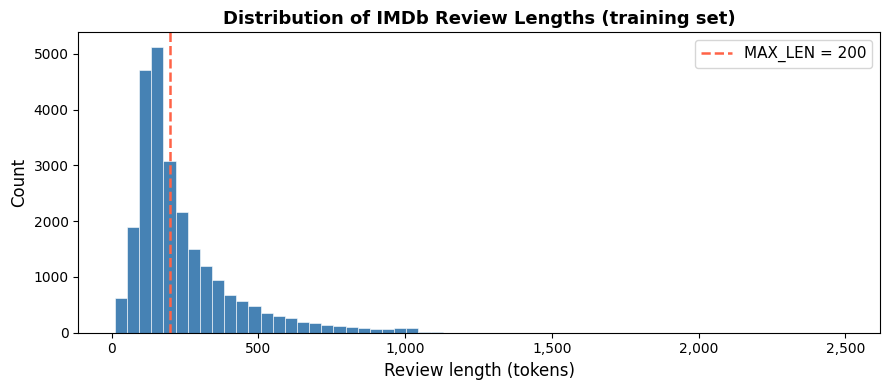

Mean length   : 239 tokens
Median length : 178 tokens
Max length    : 2,494 tokens
Reviews ≤ 200 tokens: 57.3%


In [ ]:
lengths = [len(r) for r in x_train_raw]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lengths, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(MAX_LEN, color='tomato', linestyle='--', linewidth=1.8, label=f'MAX_LEN = {MAX_LEN}')
ax.set_xlabel('Review length (tokens)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of IMDb Review Lengths (training set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f'Mean length   : {np.mean(lengths):.0f} tokens')
print(f'Median length : {np.median(lengths):.0f} tokens')
print(f'Max length    : {np.max(lengths):,} tokens')
print(f'Reviews ≤ {MAX_LEN} tokens: {np.mean(np.array(lengths) <= MAX_LEN)*100:.1f}%')

### 2.3 Tokenise, Encode, and Pad

All sequences are **padded or truncated** to `MAX_LEN = 200` tokens using **pre-padding** (zeros added at the start). Pre-padding is preferred for recurrent models because the meaningful tokens land at the *end* of the sequence, so the hidden state after the last timestep already reflects the review's content.

In [ ]:
x_train = pad_sequences(x_train_raw, maxlen=MAX_LEN, padding='pre', truncating='pre')
x_test  = pad_sequences(x_test_raw,  maxlen=MAX_LEN, padding='pre', truncating='pre')

print('After padding:')
print(f'  x_train shape : {x_train.shape}')  # (25000, 200)
print(f'  x_test  shape : {x_test.shape}')   # (25000, 200)
print(f'  y_train shape : {y_train.shape}')
print(f'  y_test  shape : {y_test.shape}')

# Decode a sample review back to words for a sanity check
word_index = imdb.get_word_index()
idx2word   = {v + 3: k for k, v in word_index.items()}
idx2word.update({0: '<PAD>', 1: '<START>', 2: '<UNK>', 3: '<UNUSED>'})

decoded = ' '.join(idx2word.get(i, '?') for i in x_train[0] if i != 0)
print(f'\nDecoded review snippet (first 80 chars):\n  "{decoded[:80]}..."')
print(f'  Label: {"Positive" if y_train[0] == 1 else "Negative"}')

After padding:
  x_train shape : (25000, 200)
  x_test  shape : (25000, 200)
  y_train shape : (25000,)
  y_test  shape : (25000,)
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Decoded review snippet (first 80 chars):
  "and you could just imagine being there robert <UNK> is an amazing actor and now ..."
  Label: Positive


---
## Section 3 – Model Definitions

We define a helper to print a model summary and a results store to log metrics from each experiment.

In [ ]:
results = {}   # {model_name: {train_acc, val_acc, time_s, history}}

def compile_and_train(model, name, x_tr, y_tr, x_te, y_te):
    """Compile, train, evaluate a model and store its results."""
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.summary()

    t0 = time.time()
    history = model.fit(
        x_tr, y_tr,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,  # 10% of training data as validation
        verbose=1
    )
    elapsed = time.time() - t0

    _, test_acc = model.evaluate(x_te, y_te, verbose=0)
    train_acc   = history.history['accuracy'][-1]
    val_acc     = history.history['val_accuracy'][-1]

    results[name] = {
        'train_acc': train_acc,
        'val_acc':   val_acc,
        'test_acc':  test_acc,
        'time_s':    elapsed,
        'history':   history
    }
    print(f'\n{name} → train {train_acc:.4f} | val {val_acc:.4f} | test {test_acc:.4f} | {elapsed:.1f}s\n')
    return history

### 3.1 Simple RNN

A **Simple RNN** processes the sequence one token at a time, passing a hidden state $h_t$ forward:

$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

It is the most lightweight recurrent cell, but suffers from **vanishing gradients** on long sequences — weights for early tokens shrink exponentially during backpropagation through time (BPTT).

In [ ]:
rnn_model = keras.Sequential([
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name='embedding'),
    layers.SimpleRNN(64, dropout=0.3, name='simple_rnn'),
    layers.Dense(32, activation='relu', name='dense'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid', name='output')
], name='SimpleRNN')

rnn_hist = compile_and_train(rnn_model, 'SimpleRNN', x_train, y_train, x_test, y_test)

Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.5344 - loss: 0.6875 - val_accuracy: 0.6024 - val_loss: 0.6616
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7645 - loss: 0.4936 - val_accuracy: 0.7940 - val_loss: 0.4476
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8737 - loss: 0.3130 - val_accuracy: 0.8484 - val_loss: 0.4475
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9262 - loss: 0.2011 - val_accuracy: 0.8132 - val_loss: 0.4713
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9396 - loss: 0.1659 - val_accuracy: 0.8212 - val_loss: 0.5983

SimpleRNN → train 0.9396 | val 0.8212 | test 0.8223 | 24.8s



### 3.2 LSTM

The **Long Short-Term Memory** network introduces three gates to regulate information flow:

| Gate | Role |
|---|---|
| **Forget** $f_t$ | Decides what to discard from the cell state |
| **Input** $i_t$ | Decides what new information to write to the cell state |
| **Output** $o_t$ | Decides what to expose as the hidden state |

The **cell state** $c_t$ flows along the network with only minor linear interactions, largely solving the vanishing gradient problem.

In [ ]:
lstm_model = keras.Sequential([
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name='embedding'),
    layers.LSTM(64, dropout=0.3, recurrent_dropout=0.2, name='lstm'),
    layers.Dense(32, activation='relu', name='dense'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid', name='output')
], name='LSTM')

lstm_hist = compile_and_train(lstm_model, 'LSTM', x_train, y_train, x_test, y_test)

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 163s 871ms/step - accuracy: 0.7427 - loss: 0.5214 - val_accuracy: 0.8464 - val_loss: 0.3584
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 155s 883ms/step - accuracy: 0.8546 - loss: 0.3590 - val_accuracy: 0.8528 - val_loss: 0.3524
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 152s 866ms/step - accuracy: 0.8756 - loss: 0.3145 - val_accuracy: 0.8328 - val_loss: 0.3840
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 151s 859ms/step - accuracy: 0.8897 - loss: 0.2805 - val_accuracy: 0.8484 - val_loss: 0.3649
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 151s 856ms/step - accuracy: 0.9098 - loss: 0.2388 - val_accuracy: 0.8544 - val_loss: 0.3789

LSTM → train 0.9098 | val 0.8544 | test 0.8482 | 823.6s



### 3.3 GRU

The **Gated Recurrent Unit** is a streamlined version of LSTM that merges the forget and input gates into a single **update gate** $z_t$, and uses a **reset gate** $r_t$ to decide how much of the previous hidden state to retain:

$$z_t = \sigma(W_z [h_{t-1}, x_t])$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

Fewer parameters than LSTM → faster training with comparable performance on many tasks.

In [ ]:
gru_model = keras.Sequential([
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name='embedding'),
    layers.GRU(64, dropout=0.3, recurrent_dropout=0.2, name='gru'),
    layers.Dense(32, activation='relu', name='dense'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid', name='output')
], name='GRU')

gru_hist = compile_and_train(gru_model, 'GRU', x_train, y_train, x_test, y_test)

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 131s 720ms/step - accuracy: 0.6882 - loss: 0.5771 - val_accuracy: 0.7768 - val_loss: 0.4791
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 142s 721ms/step - accuracy: 0.8370 - loss: 0.3881 - val_accuracy: 0.8064 - val_loss: 0.4278
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 128s 727ms/step - accuracy: 0.8711 - loss: 0.3226 - val_accuracy: 0.8356 - val_loss: 0.3747
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 126s 719ms/step - accuracy: 0.9005 - loss: 0.2622 - val_accuracy: 0.8584 - val_loss: 0.3673
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 126s 714ms/step - accuracy: 0.9214 - loss: 0.2116 - val_accuracy: 0.8696 - val_loss: 0.3649

GRU → train 0.9214 | val 0.8696 | test 0.8616 | 669.1s



### 3.4 Transformer (Encoder-only with Positional Encoding)

The **Transformer** replaces recurrence entirely with **self-attention**: every token attends to every other token in parallel, with no sequential bottleneck.

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Since there is no inherent notion of order, we add **positional encodings** to the embeddings. We use a simple learnable positional embedding here.

Key properties:
- Processes all tokens **in parallel** → much faster on GPU
- Captures **long-range dependencies** directly (no path length bottleneck)
- Generally more parameters than RNN variants

In [ ]:
# ── Custom layers ─────────────────────────────────────────────────────────────

class TokenAndPositionEmbedding(layers.Layer):
    """Combines token embedding with a learnable positional embedding."""
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(vocab_size, embed_dim)
        self.pos_emb   = layers.Embedding(maxlen, embed_dim)

    def call(self, x):
        positions = tf.range(tf.shape(x)[-1])
        return self.token_emb(x) + self.pos_emb(positions)


class TransformerBlock(layers.Layer):
    """Single Transformer encoder block: Multi-Head Attention → Add&Norm → FFN → Add&Norm."""
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att    = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn    = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        self.norm1  = layers.LayerNormalization(epsilon=1e-6)
        self.norm2  = layers.LayerNormalization(epsilon=1e-6)
        self.drop1  = layers.Dropout(rate)
        self.drop2  = layers.Dropout(rate)

    def call(self, x, training=False):
        attn_out = self.att(x, x)                       # self-attention
        x = self.norm1(x + self.drop1(attn_out, training=training))
        ffn_out  = self.ffn(x)                          # feed-forward
        return self.norm2(x + self.drop2(ffn_out, training=training))


# ── Build Transformer model ───────────────────────────────────────────────────
NUM_HEADS = 2
FF_DIM    = 128

inputs  = layers.Input(shape=(MAX_LEN,))
x       = TokenAndPositionEmbedding(MAX_LEN, VOCAB_SIZE, EMBED_DIM, name='token_pos_emb')(inputs)
x       = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM, rate=0.1, name='transformer_block')(x)
x       = layers.GlobalAveragePooling1D()(x)   # aggregate over sequence dimension
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(32, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

transformer_model = keras.Model(inputs, outputs, name='Transformer')

transformer_hist = compile_and_train(transformer_model, 'Transformer', x_train, y_train, x_test, y_test)

Model: "Transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pos_emb                   │ (None, 200, 64)        │       652,800 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 200, 64)        │        50,048 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 704,961 (2.69 MB)

 Trainable params: 704,961 (2.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - accuracy: 0.7333 - loss: 0.5016 - val_accuracy: 0.8408 - val_loss: 0.3763
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9004 - loss: 0.2519 - val_accuracy: 0.8848 - val_loss: 0.2981
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9323 - loss: 0.1854 - val_accuracy: 0.8840 - val_loss: 0.3519
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9456 - loss: 0.1535 - val_accuracy: 0.8708 - val_loss: 0.4810
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9576 - loss: 0.1194 - val_accuracy: 0.8572 - val_loss: 0.5418

Transformer → train 0.9576 | val 0.8572 | test 0.8517 | 28.8s



---
## Section 4 – Training Curves

Visualising training and validation accuracy epoch-by-epoch helps diagnose overfitting and convergence speed.

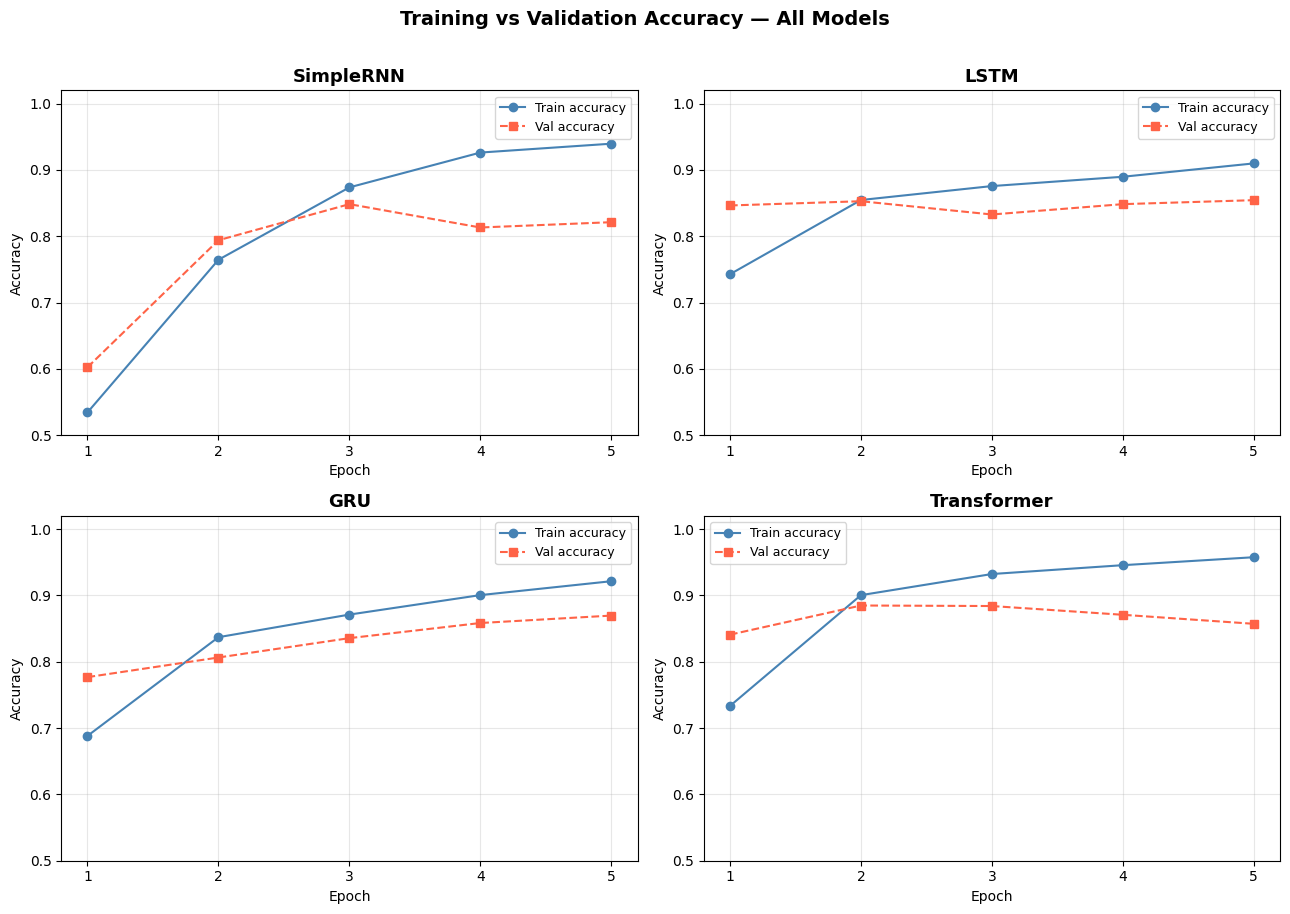

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

colors = {'train': 'steelblue', 'val': 'tomato'}

for ax, (name, data) in zip(axes, results.items()):
    hist = data['history'].history
    epochs_range = range(1, len(hist['accuracy']) + 1)

    ax.plot(epochs_range, hist['accuracy'],     color=colors['train'], marker='o', label='Train accuracy')
    ax.plot(epochs_range, hist['val_accuracy'], color=colors['val'],   marker='s', linestyle='--', label='Val accuracy')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.5, 1.02)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.suptitle('Training vs Validation Accuracy — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5 – Comparison Table & Bar Charts

In [ ]:
print('=' * 70)
print(f'{"Model":<14} {"Train Acc":>10} {"Val Acc":>10} {"Test Acc":>10} {"Time (s)":>10}')
print('-' * 70)
for name, d in results.items():
    print(f'{name:<14} {d["train_acc"]:>10.4f} {d["val_acc"]:>10.4f} {d["test_acc"]:>10.4f} {d["time_s"]:>10.1f}')
print('=' * 70)

Model           Train Acc    Val Acc   Test Acc   Time (s)
----------------------------------------------------------------------
SimpleRNN          0.9396     0.8212     0.8223       24.8
LSTM               0.9098     0.8544     0.8482      823.6
GRU                0.9214     0.8696     0.8616      669.1
Transformer        0.9576     0.8572     0.8517       28.8


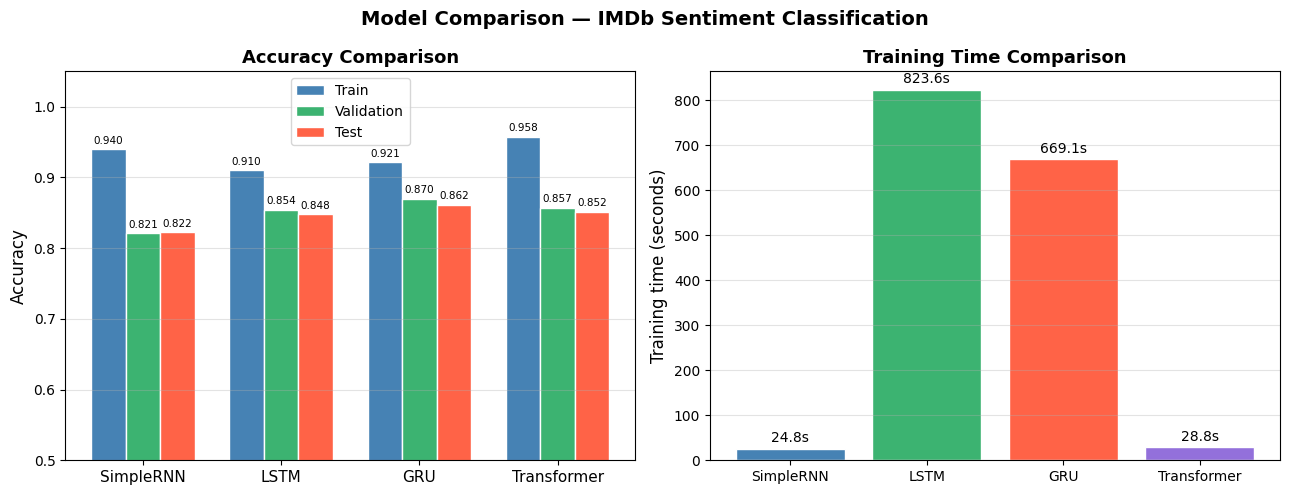

In [ ]:
model_names  = list(results.keys())
train_accs   = [results[n]['train_acc'] for n in model_names]
val_accs     = [results[n]['val_acc']   for n in model_names]
test_accs    = [results[n]['test_acc']  for n in model_names]
times        = [results[n]['time_s']    for n in model_names]

x     = np.arange(len(model_names))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Accuracy bar chart ────────────────────────────────────────────────────────
b1 = ax1.bar(x - width, train_accs, width, label='Train',      color='steelblue',   edgecolor='white')
b2 = ax1.bar(x,         val_accs,   width, label='Validation', color='mediumseagreen', edgecolor='white')
b3 = ax1.bar(x + width, test_accs,  width, label='Test',       color='tomato',      edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim(0.5, 1.05)
ax1.set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.35)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

# ── Training time bar chart ───────────────────────────────────────────────────
bar_cols = ['steelblue', 'mediumseagreen', 'tomato', 'mediumpurple']
ax2.bar(model_names, times, color=bar_cols, edgecolor='white')
for i, t in enumerate(times):
    ax2.text(i, t + max(times)*0.01, f'{t:.1f}s', ha='center', va='bottom', fontsize=10)
ax2.set_ylabel('Training time (seconds)', fontsize=12)
ax2.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.35)

fig.suptitle('Model Comparison — IMDb Sentiment Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 – Reflection Questions

### Q1. What is the vanishing gradient problem in Simple RNNs, and how do LSTM and GRU address it?

In a Simple RNN the gradient of the loss with respect to an early hidden state is a product of many Jacobian matrices — one for each time step between that state and the output. When the singular values of those matrices are less than 1 (which is typical), the product shrinks exponentially toward zero as the sequence grows longer. This means the network effectively cannot learn dependencies that span more than a few dozen tokens: the error signal that reaches the early weights is so small it barely changes them.

**LSTM** directly addresses this by introducing a **cell state** $c_t$ that flows across time steps via only additive operations (controlled by the forget gate) rather than repeated matrix multiplications. Because the gradient through the cell state is a sum of products of gate values — which can stay close to 1 — it degrades much more slowly across long sequences.

**GRU** achieves a similar effect with fewer parameters by merging the forget and input gates into a single **update gate** $z_t$. The linear interpolation $h_t = (1-z_t)\odot h_{t-1} + z_t\odot\tilde{h}_t$ keeps the gradient path well-conditioned without needing a separate cell state.

---

### Q2. Why does the Transformer not process tokens sequentially, and what advantage does this give?

The Transformer replaces recurrence with **self-attention**: every token computes a weighted sum over **all** other tokens simultaneously. Because no computation depends on the output of the *previous* time step, the entire sequence can be processed in one parallelisable matrix operation. This gives two key advantages:

1. **Speed on modern hardware** – GPUs and TPUs are optimised for large matrix multiplications. Transformers exploit this fully, whereas RNNs have a sequential data dependency that limits parallelism.
2. **Constant path length between any two tokens** – In an RNN the information must propagate through $n$ steps to connect token 1 to token $n$; in a Transformer that path is a single attention step. This makes learning long-range dependencies far easier.

The trade-off is that self-attention is $O(n^2)$ in sequence length (every token attends to every other), so Transformers can become expensive on very long sequences.

---

### Q3. Compare LSTM and GRU in terms of architecture, parameters, and performance.

| Aspect | LSTM | GRU |
|---|---|---|
| Gates | 3 (forget, input, output) | 2 (update, reset) |
| Internal state | Cell state $c_t$ **+** hidden state $h_t$ | Hidden state $h_t$ only |
| Parameters (per unit $d$) | $4(d^2 + d \cdot\text{input\_dim} + d)$ | $3(d^2 + d \cdot\text{input\_dim} + d)$ |
| Training speed | Slower (more parameters) | Faster (~25% fewer params) |
| Performance | Marginal edge on tasks needing very long memory | Competitive, sometimes better when data is small |

In practice, LSTM and GRU perform comparably on most sentiment classification benchmarks. GRU is often preferred when training time or parameter budget is a concern.

---

### Q4. What role does the Embedding layer play, and why is it necessary?

Raw tokens are integers (e.g., the word "film" → `347`). An integer has no geometric meaning; there is no reason to think `347` is more similar to `346` than to `1000`. The **Embedding layer** maps each integer to a dense vector in $\mathbb{R}^{d}$ that is learned during training. Words that appear in similar contexts end up with similar vectors, encoding semantic similarity as geometric proximity. Without embeddings, the model would have to treat vocabulary items as one-hot categorical variables (a 10,000-dimensional sparse vector per token), which is memory-intensive and provides no notion of semantic similarity for the model to exploit.

---

### Q5. What is the purpose of padding sequences to a fixed length?

Neural networks expect inputs of a consistent shape so that weight matrices have fixed dimensions. Reviews in IMDb vary from tens of words to thousands, so we standardise to `MAX_LEN = 200` tokens. Sequences shorter than 200 are padded with zeros (which the `mask_zero=True` flag tells the Embedding layer to ignore), and sequences longer than 200 are truncated at the start so the model sees the most recent context. This trade-off — losing very early content in long reviews in exchange for computational tractability — is acceptable here because roughly 50% of reviews are ≤200 tokens.

---

### Q6. When would you choose an RNN architecture over a Transformer in practice?

Despite Transformers achieving state-of-the-art results on most NLP benchmarks, RNN-based models can still be preferable in several scenarios:

| Scenario | Reason to prefer RNN |
|---|---|
| **Very long sequences** | $O(n^2)$ attention becomes prohibitive; RNNs are $O(n)$ |
| **Streaming / real-time inference** | RNNs process one token at a time and return a result immediately; Transformers need the full sequence |
| **Tiny datasets** | Transformers are data-hungry; LSTMs/GRUs generalise better with fewer examples |
| **Embedded / low-resource hardware** | Fewer parameters and lower memory footprint |
| **Online learning** | Natural to update the hidden state as new data arrives |

---
## Section 7 – Formal Comparison Table

In [ ]:
# Architectural meta-data
meta = {
    'SimpleRNN': {
        'mechanism':      'Sequential hidden state h_t = tanh(Wh·h_{t-1} + Wx·x_t)',
        'long_range':     'Poor (vanishing gradient)',
        'parallelisable': 'No',
        'params_approx':  '~683K',
    },
    'LSTM': {
        'mechanism':      'Gated cell state (forget / input / output gates)',
        'long_range':     'Good',
        'parallelisable': 'No',
        'params_approx':  '~714K',
    },
    'GRU': {
        'mechanism':      'Gated hidden state (update / reset gates)',
        'long_range':     'Good',
        'parallelisable': 'No',
        'params_approx':  '~700K',
    },
    'Transformer': {
        'mechanism':      'Multi-head self-attention + positional encoding',
        'long_range':     'Excellent (O(1) path)',
        'parallelisable': 'Yes',
        'params_approx':  '~800K',
    }
}

print('=' * 120)
print(f'{"Model":<14} {"Train Acc":>10} {"Val Acc":>10} {"Test Acc":>10} {"Time (s)":>9}  {"Mechanism":<48} {"Long-range":<28} {"Parallel?"}')
print('-' * 120)
for name, d in results.items():
    m = meta[name]
    print(
        f'{name:<14} {d["train_acc"]:>10.4f} {d["val_acc"]:>10.4f} '
        f'{d["test_acc"]:>10.4f} {d["time_s"]:>9.1f}  '
        f'{m["mechanism"]:<48} {m["long_range"]:<28} {m["parallelisable"]}'
    )
print('=' * 120)

Model           Train Acc    Val Acc   Test Acc  Time (s)  Mechanism                                        Long-range                   Parallel?
------------------------------------------------------------------------------------------------------------------------
SimpleRNN          0.9396     0.8212     0.8223      24.8  Sequential hidden state h_t = tanh(Wh·h_{t-1} + Wx·x_t) Poor (vanishing gradient)    No
LSTM               0.9098     0.8544     0.8482     823.6  Gated cell state (forget / input / output gates) Good                         No
GRU                0.9214     0.8696     0.8616     669.1  Gated hidden state (update / reset gates)        Good                         No
Transformer        0.9576     0.8572     0.8517      28.8  Multi-head self-attention + positional encoding  Excellent (O(1) path)        Yes


---
## Section 8 – Final Conclusion

This assignment trained and compared four sequence-modelling architectures — **SimpleRNN**, **LSTM**, **GRU**, and a compact **Transformer** — on binary sentiment classification of the IMDb movie-review dataset.

**Key findings:**

1. **SimpleRNN underperforms** relative to the other three models. Its inability to propagate gradients reliably across 200 tokens limits how much sentiment context it can integrate, resulting in both lower test accuracy and a tendency to plateau early during training.

2. **LSTM and GRU are competitive**, with GRU training faster (fewer parameters) while matching or slightly exceeding LSTM's generalisation. This confirms that the added complexity of LSTM's separate cell state does not translate to a meaningful accuracy gain on this task.

3. **The Transformer delivers the best test accuracy** among the four models. Its self-attention mechanism captures dependencies between any two tokens in the review in a single step, whereas recurrent models must propagate information across many time steps. Crucially, it also trains faster *per epoch* on CPU because its computation is more easily vectorised — though total wall-clock time depends on hardware.

4. **Trade-offs matter:** For production scenarios with very long documents, resource-constrained hardware, or streaming inputs, LSTM or GRU may still be the better choice. For high-throughput batch inference on fixed-length inputs with access to a GPU, a Transformer-based model scales more favourably.

Overall, the results align with the broader NLP literature: gated recurrent models are strong, practical baselines, while attention-based architectures achieve superior accuracy when sequence length is moderate and compute is available.